# WP diagram: Lotka-Volterra

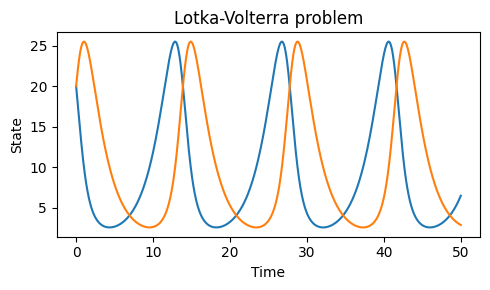

  0%|                                                     | 0/7 [00:00<?, ?it/s]

 14%|██████▍                                      | 1/7 [00:01<00:06,  1.05s/it]

 29%|████████████▊                                | 2/7 [00:01<00:04,  1.06it/s]

 43%|███████████████████▎                         | 3/7 [00:02<00:03,  1.08it/s]

 57%|█████████████████████████▋                   | 4/7 [00:03<00:01,  1.50it/s]

 71%|████████████████████████████████▏            | 5/7 [00:03<00:01,  1.99it/s]

 86%|██████████████████████████████████████▌      | 6/7 [00:03<00:00,  1.96it/s]

100%|█████████████████████████████████████████████| 7/7 [00:04<00:00,  2.39it/s]

100%|█████████████████████████████████████████████| 7/7 [00:04<00:00,  1.73it/s]

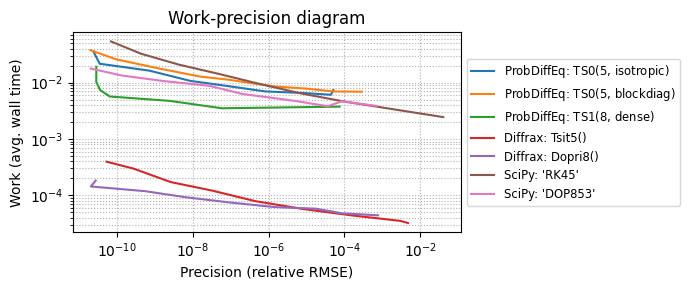

In [1]:
"""Lotka-Volterra work-precision diagram."""

import functools
import statistics
import timeit
from collections.abc import Callable

import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate
import tqdm

from probdiffeq import ivpsolve, probdiffeq, taylor

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main(start=3.0, stop=12.0, step=1.0, repeats=2) -> None:
    """Run the script."""
    # Set up all the configs
    jax.config.update("jax_enable_x64", True)

    # Simulate once to plot the state
    ts, ys = solve_ivp_once()

    _fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(ts, ys)
    ax.set_title("Lotka-Volterra problem")
    ax.set_xlabel("Time")
    ax.set_ylabel("State")
    plt.tight_layout()
    plt.show()

    # Read configuration from command line
    tolerances = setup_tolerances(start=start, stop=stop, step=step)
    timeit_fun = setup_timeit(repeats=repeats)

    # Assemble algorithms
    ts0, ts1 = probdiffeq.constraint_ode_ts0, probdiffeq.constraint_ode_ts1
    ts0_iso = solver_probdiffeq(5, constraint=ts0, implementation="isotropic")
    ts0_bd = solver_probdiffeq(5, constraint=ts0, implementation="blockdiag")
    ts1_dense = solver_probdiffeq(8, constraint=ts1, implementation="dense")
    algorithms = {
        r"ProbDiffEq: TS0($5$, isotropic)": ts0_iso,
        r"ProbDiffEq: TS0($5$, blockdiag)": ts0_bd,
        r"ProbDiffEq: TS1($8$, dense)": ts1_dense,
        "Diffrax: Tsit5()": solver_diffrax(solver=diffrax.Tsit5()),
        "Diffrax: Dopri8()": solver_diffrax(solver=diffrax.Dopri8()),
        "SciPy: 'RK45'": solver_scipy(method="RK45"),
        "SciPy: 'DOP853'": solver_scipy(method="DOP853"),
    }

    # Compute a reference solution
    reference = solver_scipy(method="BDF")(1e-13)
    precision_fun = rmse_relative(reference)

    # Compute all work-precision diagrams
    results = {}
    for label, algo in tqdm.tqdm(algorithms.items()):
        param_to_wp = workprec(algo, precision_fun=precision_fun, timeit_fun=timeit_fun)
        results[label] = param_to_wp(tolerances)

    _fig, ax = plt.subplots(figsize=(7, 3))
    for label, wp in results.items():
        ax.loglog(wp["precision"], wp["work_mean"], label=label)

    ax.set_title("Work-precision diagram")
    ax.set_xlabel("Precision (relative RMSE)")
    ax.set_ylabel("Work (avg. wall time)")
    ax.grid(linestyle="dotted", which="both")
    ax.legend(fontsize="small", loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()


def solve_ivp_once():
    """Compute plotting-values for the IVP."""

    def vf_scipy(_t, y):
        """Lotka--Volterra dynamics."""
        dy1 = 0.5 * y[0] - 0.05 * y[0] * y[1]
        dy2 = -0.5 * y[1] + 0.05 * y[0] * y[1]
        return np.asarray([dy1, dy2])

    u0 = jnp.asarray((20.0, 20.0))
    time_span = np.asarray([0.0, 50.0])
    tol = 1e-12
    solution = scipy.integrate.solve_ivp(
        vf_scipy, y0=u0, t_span=time_span, atol=1e-3 * tol, rtol=tol, method="LSODA"
    )
    return solution.t, solution.y.T


def setup_tolerances(*, start: float, stop: float, step: float) -> jax.Array:
    """Choose vector of tolerances from the command-line arguments."""
    return 0.1 ** jnp.arange(start, stop, step=step)


def setup_timeit(*, repeats: int) -> Callable:
    """Construct a timeit-function from the command-line arguments."""

    def timer(fun, /):
        return list(timeit.repeat(fun, number=1, repeat=repeats))

    return timer


def solver_probdiffeq(num_derivatives: int, implementation, constraint) -> Callable:
    """Construct a solver that wraps ProbDiffEq's solution routines."""

    @jax.jit
    def vf_probdiffeq(y, /, *, t):  # noqa: ARG001
        """Lotka--Volterra dynamics."""
        dy1 = 0.5 * y[0] - 0.05 * y[0] * y[1]
        dy2 = -0.5 * y[1] + 0.05 * y[0] * y[1]
        return jnp.asarray([dy1, dy2])

    u0 = jnp.asarray((20.0, 20.0))
    t0, t1 = (0.0, 50.0)

    @jax.jit
    def param_to_solution(tol):
        vf_auto = functools.partial(vf_probdiffeq, t=t0)
        tcoeffs = taylor.odejet_padded_scan(vf_auto, (u0,), num=num_derivatives)

        init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact=implementation)
        iwp = probdiffeq.prior_wiener_integrated(ssm=ssm)
        strategy = probdiffeq.strategy_filter(ssm=ssm)
        ts = constraint(vf_probdiffeq, ssm=ssm)
        solver = probdiffeq.solver_mle(
            strategy=strategy, prior=iwp, constraint=ts, ssm=ssm
        )
        error = probdiffeq.error_residual_std(constraint=ts, prior=iwp, ssm=ssm)

        control = ivpsolve.control_proportional_integral()
        solve = ivpsolve.solve_adaptive_terminal_values(
            error=error, solver=solver, control=control
        )
        dt0 = ivpsolve.dt0(vf_auto, (u0,))

        # Build a solver
        solution = solve(init, t0=t0, t1=t1, dt0=dt0, atol=1e-2 * tol, rtol=tol)

        # Return the terminal value
        return jax.block_until_ready(solution.u.mean[0])

    return param_to_solution


def solver_diffrax(*, solver) -> Callable:
    """Construct a solver that wraps Diffrax' solution routines."""

    @diffrax.ODETerm
    @jax.jit
    def vf_diffrax(_t, y, _args):
        """Lotka--Volterra dynamics."""
        dy1 = 0.5 * y[0] - 0.05 * y[0] * y[1]
        dy2 = -0.5 * y[1] + 0.05 * y[0] * y[1]
        return jnp.asarray([dy1, dy2])

    u0 = jnp.asarray((20.0, 20.0))
    t0, t1 = (0.0, 50.0)

    @jax.jit
    def param_to_solution(tol):
        controller = diffrax.PIDController(atol=1e-3 * tol, rtol=tol)
        saveat = diffrax.SaveAt(t0=False, t1=True, ts=None)
        solution = diffrax.diffeqsolve(
            vf_diffrax,
            y0=u0,
            t0=t0,
            t1=t1,
            saveat=saveat,
            stepsize_controller=controller,
            dt0=None,
            max_steps=10_000,
            solver=solver,
        )
        return jax.block_until_ready(solution.ys[0, :])

    return param_to_solution


def solver_scipy(*, method: str) -> Callable:
    """Construct a solver that wraps SciPy's solution routines."""

    def vf_scipy(_t, y):
        """Lotka--Volterra dynamics."""
        dy1 = 0.5 * y[0] - 0.05 * y[0] * y[1]
        dy2 = -0.5 * y[1] + 0.05 * y[0] * y[1]
        return np.asarray([dy1, dy2])

    u0 = jnp.asarray((20.0, 20.0))
    time_span = np.asarray([0.0, 50.0])

    def param_to_solution(tol):
        solution = scipy.integrate.solve_ivp(
            vf_scipy,
            y0=u0,
            t_span=time_span,
            t_eval=time_span,
            atol=1e-3 * tol,
            rtol=tol,
            method=method,
        )
        return jnp.asarray(solution.y[:, -1])

    return param_to_solution


def rmse_relative(expected: jax.Array, *, nugget=1e-5) -> Callable:
    """Compute the relative RMSE."""
    expected = jnp.asarray(expected)

    def rmse(received):
        received = jnp.asarray(received)
        error_absolute = jnp.abs(expected - received)
        error_relative = error_absolute / jnp.abs(nugget + expected)
        return jnp.linalg.norm(error_relative) / jnp.sqrt(error_relative.size)

    return rmse


def workprec(fun, *, precision_fun: Callable, timeit_fun: Callable) -> Callable:
    """Turn a parameter-to-solution function into parameter-to-workprecision."""

    def parameter_list_to_workprecision(list_of_args, /):
        works_mean = []
        works_std = []
        precisions = []
        for arg in list_of_args:
            precision = precision_fun(fun(arg).block_until_ready())
            times = timeit_fun(lambda: fun(arg).block_until_ready())  # noqa: B023

            precisions.append(precision)
            works_mean.append(statistics.mean(times))
            works_std.append(statistics.stdev(times))
        return {
            "work_mean": jnp.asarray(works_mean),
            "work_std": jnp.asarray(works_std),
            "precision": jnp.asarray(precisions),
        }

    return parameter_list_to_workprecision


main()